In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

import spatialtools as st

figure_dir = "figures/revision/figure-4"
st.utils.setup_plotting(figure_dir)

import os

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns

In [2]:
path = "data/xenium/processed/05.2-kidney_tcr_infilrate.h5ad"
adata = sc.read_h5ad(path)
adata.obs["cell_id"] = adata.obs.index.str.split("output").str[0]
adata = adata[adata.obs["condition"] == "ANCA"].copy()
adata

AnnData object with n_obs × n_vars = 389390 × 480
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density', 'tcell_infiltrate', 'cell_id'
    var: 'n_

In [3]:
adata.obs["sample"].unique().tolist()

['XETG00088__0029040__Region_4__20240719__095642',
 'XETG00088__0029041__Region_3__20240719__095642',
 'XETG00088__0029041__Region_5__20240719__095642',
 'XETG00088__0029040__Region_7__20240719__095642',
 'XETG00088__0029040__Region_6__20240719__095642',
 'XETG00088__0029041__Region_4__20240719__095642',
 'XETG00088__0029041__Region_8__20240719__095642',
 'XETG00088__0029041__Region_7__20240719__095642',
 'XETG00088__0029041__Region_6__20240719__095642',
 'XETG00088__0029040__Region_5__20240719__095642']

In [4]:
adata.obs["infiltrate+glom+gdT"] = adata.obs["tcell_infiltrate"].astype(str)
mapping = {"infiltrate": "T cell infiltrate", "no infiltrate": "other"}
adata.obs["infiltrate+glom+gdT"] = adata.obs["infiltrate+glom+gdT"].map(mapping)

# add glom annotations
adata.obs.loc[adata.obs["in_glom"], "infiltrate+glom+gdT"] = "inside glom."

# add gdT annotations
adata.obs.loc[adata.obs["cell_type_l2"] == "gdT", "infiltrate+glom+gdT"] = "gdT"

categories = ["other", "T cell infiltrate", "inside glom.", "gdT"]

# reorder categories
adata.obs["infiltrate+glom+gdT"] = adata.obs["infiltrate+glom+gdT"].astype("category")
adata.obs["infiltrate+glom+gdT"] = adata.obs[
    "infiltrate+glom+gdT"
].cat.reorder_categories(categories)
adata.obs["infiltrate+glom+gdT"].value_counts()

infiltrate+glom+gdT
other                342523
T cell infiltrate     28224
inside glom.          18203
gdT                     440
Name: count, dtype: int64

In [5]:
sample = adata.obs["sample"].unique()[3]

ad_sub = adata[adata.obs["sample"] == sample].copy()

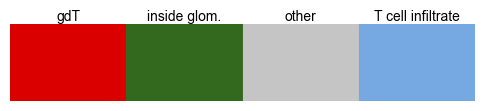

In [6]:
from spatial_tcr.colors import colors_sub

palette = sns.color_palette("deep", 4)
palette = dict(zip(categories, palette))
palette["gdT"] = "red"

palette = {
    "gdT": colors_sub["gdT"],
    "inside glom.": colors_sub["glom. cell"],
    "other": "#c5c5c5",
    "T cell infiltrate": "#76a9e2",
}
st.pl.utils.plot_palette_dict(palette)

/tmp/ipykernel_3621870/3402811351.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


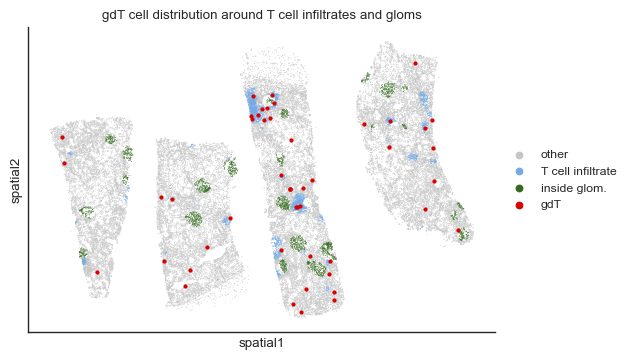

In [7]:
fig = sc.pl.spatial(
    ad_sub, color="infiltrate+glom+gdT", spot_size=10, show=False, palette=palette
)
ax = fig[0]
ad_sub_gdt = ad_sub[ad_sub.obs["cell_type_l2"] == "gdT"]
ax.scatter(
    ad_sub_gdt.obsm["spatial"][:, 0],
    ad_sub_gdt.obsm["spatial"][:, 1],
    s=5,
    c=palette["gdT"],
)
ax.set_title("gdT cell distribution around T cell infiltrates and gloms")
sns.despine(ax=ax)
plt.tight_layout()
# plt.savefig(os.path.join(figure_dir, "gdT_infiltrate_glom_distribution.pdf"), dpi=300)

## New plot with zoom in

In [8]:
base_dir = "/bonn-epyc/projects/spatialTCR/20240719__094819__human_kidney_7_TCR"

samples = adata.obs["sample"].unique()
sample_to_data_dir = dict(
    zip(samples, [os.path.join(base_dir, f"output-{sample}") for sample in samples])
)
cc_to_sample = adata.obs[["cc", "sample"]].apply(np.array).drop_duplicates().values
cc_to_sample = dict(zip(cc_to_sample[:, 0], cc_to_sample[:, 1]))

cc_to_data_dir = {cc: sample_to_data_dir[sample] for cc, sample in cc_to_sample.items()}

In [9]:
# sample_key = "cc"
# sample = "17"
sample_key = "sample"
data_dir = sample_to_data_dir[sample]

ad_sub = st.pl.utils.add_spatial_data(
    adata,
    data_dir,
    sample_key=sample_key,
    sample=sample,
    cell_id_key="cell_id",
    level=0,
)
ad_sub.obs_names = ad_sub.obs["cell_id"].tolist()

Loading images from ['/bonn-epyc/projects/spatialTCR/20240719__094819__human_kidney_7_TCR/output-XETG00088__0029040__Region_7__20240719__095642/morphology_focus/morphology_focus_0000.ome.tif', '/bonn-epyc/projects/spatialTCR/20240719__094819__human_kidney_7_TCR/output-XETG00088__0029040__Region_7__20240719__095642/morphology_focus/morphology_focus_0001.ome.tif', '/bonn-epyc/projects/spatialTCR/20240719__094819__human_kidney_7_TCR/output-XETG00088__0029040__Region_7__20240719__095642/morphology_focus/morphology_focus_0002.ome.tif', '/bonn-epyc/projects/spatialTCR/20240719__094819__human_kidney_7_TCR/output-XETG00088__0029040__Region_7__20240719__095642/morphology_focus/morphology_focus_0003.ome.tif']


  0%|          | 0/4 [00:00<?, ?it/s]

The image has shape: (20504, 28471, 4) with channel names: ['DAPI', 'CD45', 'RNA', 'Vimentin']
cell_ids_sub: ['aaaaalcj-1', 'aaaaneng-1', 'aaabkkee-1', 'aaadbjpp-1', 'aaadhpcp-1', 'aaaklkll-1', 'aaakocnb-1', 'aabafgam-1', 'aabcgdhd-1', 'aabcpfck-1', 'aabdcccl-1', 'aabdcolm-1', 'aabgocfh-1', 'aabhfchg-1', 'aabhhgao-1', 'aabiffek-1', 'aabilldi-1', 'aabjnffp-1', 'aabjnkba-1', 'aablniap-1', 'aabmmfbi-1', 'aabnnhbf-1', 'aabocemh-1', 'aabongbj-1', 'aabopeeb-1', 'aacaepeg-1', 'aacalcjj-1', 'aacbpcjh-1', 'aaccemec-1', 'aacddeeb-1', 'aacelcma-1', 'aaceohab-1', 'aacfeplb-1', 'aaciidmo-1', 'aacjjneh-1', 'aacoglfj-1', 'aadaibok-1', 'aadbfnnj-1', 'aadcfaal-1', 'aadcfdko-1', 'aaddnbpe-1', 'aadfpblh-1', 'aadjncdh-1', 'aadmjhpo-1', 'aadmphnm-1', 'aadndmln-1', 'aadnfgig-1', 'aadoebhj-1', 'aadojkdc-1', 'aadpfehf-1', 'aaeabcfh-1', 'aaeahegk-1', 'aaeaneof-1', 'aaebbiij-1', 'aaebemkg-1', 'aaecklkk-1', 'aaeclfoi-1', 'aaecnfgf-1', 'aaedeoog-1', 'aaedocej-1', 'aaeeanfg-1', 'aaejdjaa-1', 'aaepejmg-1', 'aaephin

In [10]:
plot_col = "infiltrate+glom+gdT"

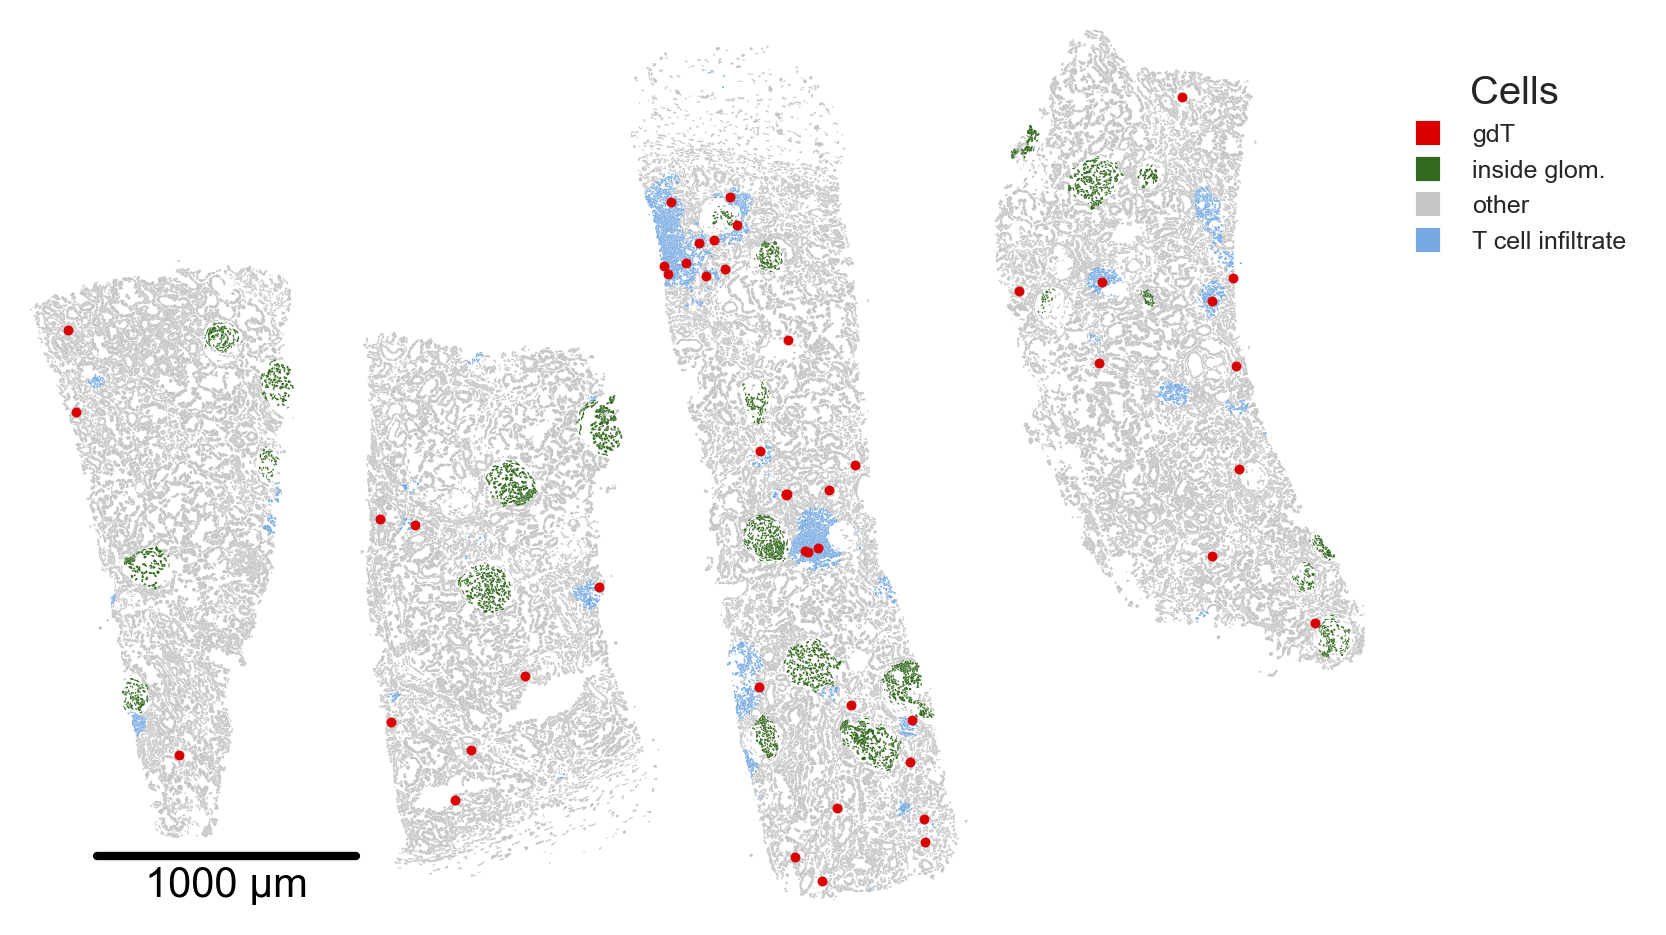

In [11]:
fig, ax = st.pl.spatial.plot_spatial(
    ad_sub,
    # plot_nuc=True,
    plot_nuc=False,
    plot_cell=True,
    plot_img=False,
    # genes=["PECAM1"],
    dpi=300,
    cell_color=plot_col,
    # img_kwargs={"vmax": [3000, 5000, 3000]},
    img_kwargs={"vmax": 5000},
    show=False,
    # gene_kwargs={"s": 1},
    cell_kwargs={
        "palette": palette,
        "edgecolor": "none",
        "rasterized": True,
    },
    figsize=(5, 10),
    labelsize=3,
    tick_size=1000,
    img_channel=[
        # "CD45",
        # "RNA",
        "DAPI",
    ],
    grid=True,
    frameon=False,
    show_scale_bar=True,
    scale_bar_kwargs={"color": "black"},
    show_legend=True,
)
# highlight gdTs
mask = ad_sub.obs["cell_type_l2"] == "gdT"
x, y = ad_sub[mask].obsm["spatial_scaled"].T
ax.scatter(x, y, s=2.5, c=palette["gdT"])

plt.savefig(
    os.path.join(figure_dir, "gdT_infiltrate_glom_distribution.pdf"),
    dpi=1000,
    bbox_inches="tight",
)

### Plot zoom in

In [12]:
palette_alpha = {
    ct: mcolors.to_rgba(palette[ct], alpha=0.0 if ct == "NA" else 0.8)
    for ct in palette.keys()
}
palette_alpha["gdT"] = palette["gdT"]

Loading images from ['/bonn-epyc/projects/spatialTCR/20240719__094819__human_kidney_7_TCR/output-XETG00088__0029040__Region_7__20240719__095642/morphology_focus/morphology_focus_0000.ome.tif', '/bonn-epyc/projects/spatialTCR/20240719__094819__human_kidney_7_TCR/output-XETG00088__0029040__Region_7__20240719__095642/morphology_focus/morphology_focus_0001.ome.tif', '/bonn-epyc/projects/spatialTCR/20240719__094819__human_kidney_7_TCR/output-XETG00088__0029040__Region_7__20240719__095642/morphology_focus/morphology_focus_0002.ome.tif', '/bonn-epyc/projects/spatialTCR/20240719__094819__human_kidney_7_TCR/output-XETG00088__0029040__Region_7__20240719__095642/morphology_focus/morphology_focus_0003.ome.tif']


  0%|          | 0/4 [00:00<?, ?it/s]

The image has shape: (20504, 28471, 4) with channel names: ['DAPI', 'CD45', 'RNA', 'Vimentin']
cell_ids_sub: ['adndokbp-1', 'adnifiil-1', 'adnihmnk-1', 'adohnfeg-1', 'adokehec-1', 'adongkol-1', 'adonkigo-1', 'adopcdjl-1', 'adpcgdml-1', 'adpdonlm-1', 'adpegjjb-1', 'adpfpnfh-1', 'afbjgjmf-1', 'afbjngbk-1', 'afbkblng-1', 'afbkcbak-1', 'afblcgbd-1', 'afbmpelj-1', 'afbnkfnb-1', 'afbonmob-1', 'afbplgld-1', 'afcbghfk-1', 'afccjbab-1', 'afdbmman-1', 'afdcackk-1', 'afddahoh-1', 'afddcggp-1', 'afdfnadg-1', 'afdgdapm-1', 'afdgnkib-1', 'afdjejdk-1', 'afdjenfd-1', 'afdkaneh-1', 'afdkoadl-1', 'afdmhbmp-1', 'afdmmpcj-1', 'afdmpcbn-1', 'afdokbpo-1', 'afebhfme-1', 'aoebkgom-1', 'aoeblopk-1', 'aoefbpbm-1', 'aoegamab-1', 'aoeghcbd-1', 'aoehfecj-1', 'aoehnkpi-1', 'aoehofeo-1', 'aoepgekg-1', 'aogkpcll-1', 'aogmheaj-1', 'aognacgj-1', 'aognikgp-1', 'aogpjdhm-1', 'aohcolbm-1', 'aohdbppg-1', 'aohechbj-1', 'aohgijfc-1', 'aohkpbbg-1', 'aohlelgk-1', 'aohmmlga-1', 'aohnbonk-1', 'aohnkikh-1', 'aohoabhd-1', 'aohoepc

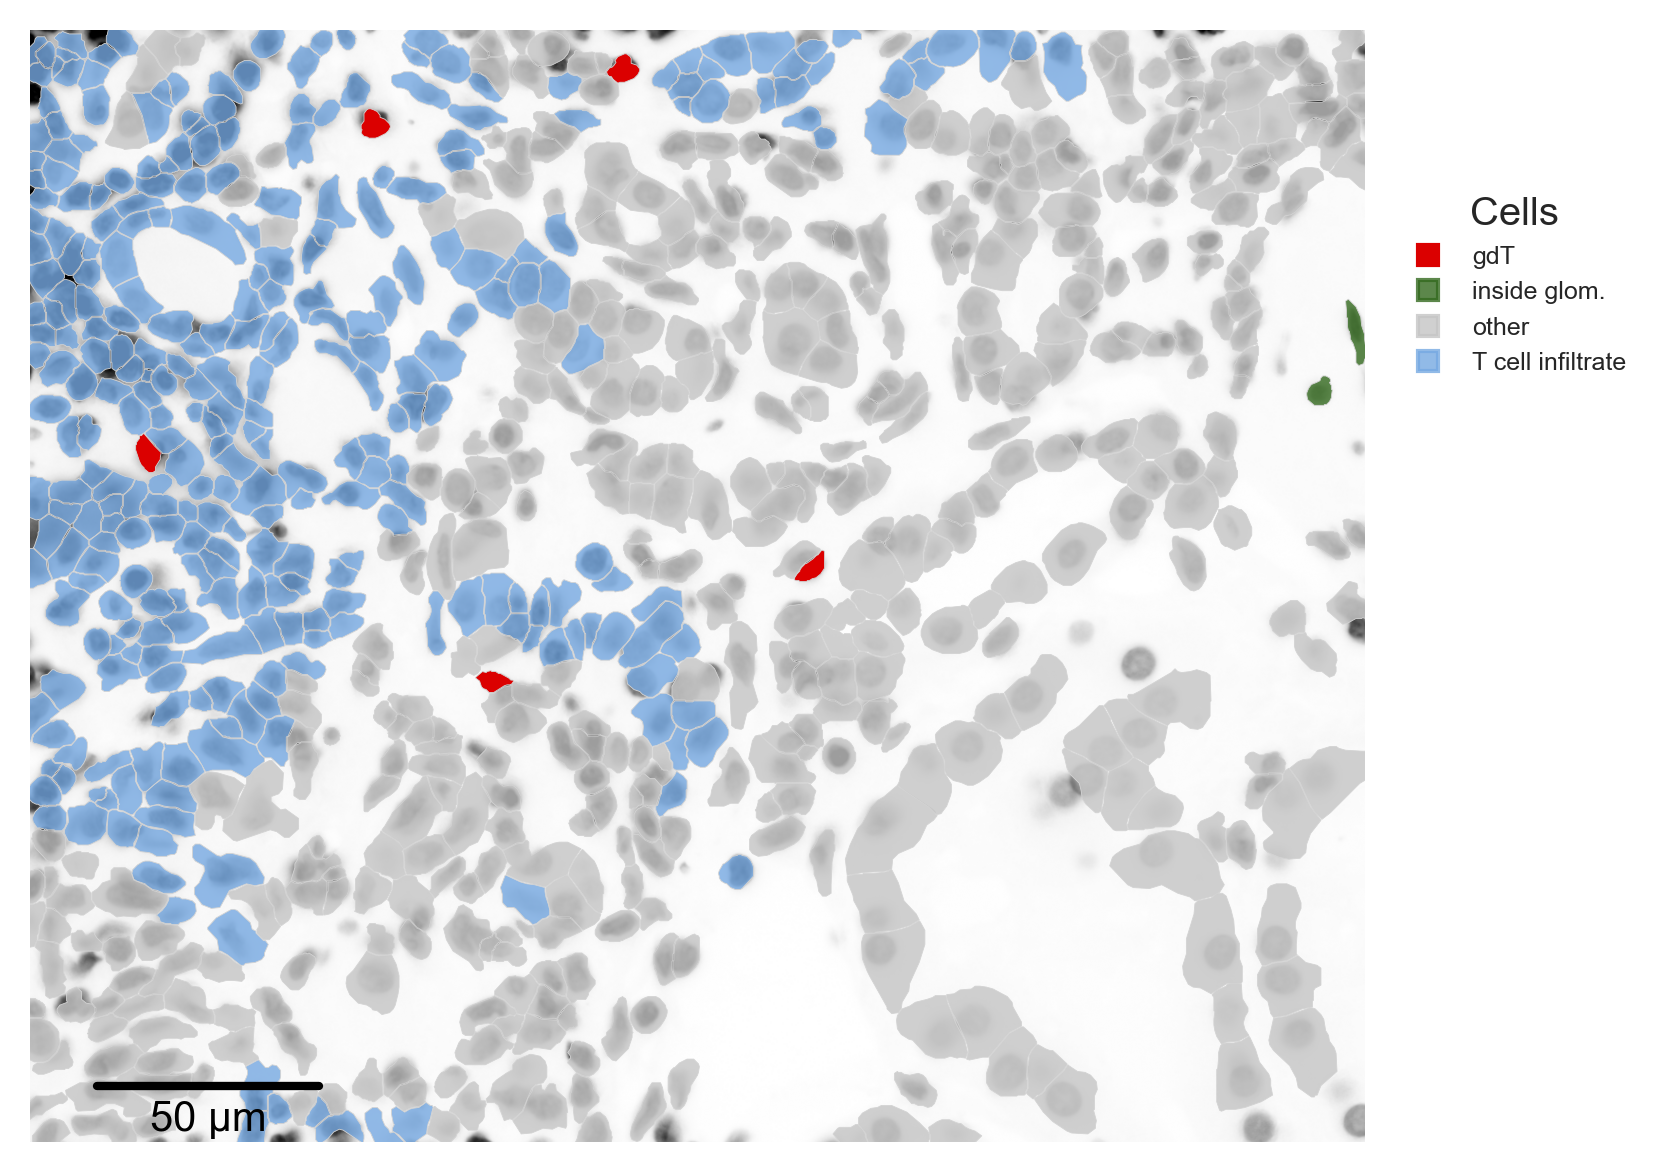

In [13]:
xlim = [2500, 2800]
ylim = [800, 1050]

ad_zoom_1 = st.pl.utils.add_spatial_data(
    ad_sub,
    data_dir,
    xlim=xlim,
    ylim=ylim,
    cell_id_key="cell_id",
    level=0,
)
ad_zoom_1.obs_names = ad_zoom_1.obs["cell_id"].tolist()

fig, ax, legend = st.pl.spatial.plot_spatial(
    ad_zoom_1,
    plot_cell=True,
    dpi=300,
    cell_color=plot_col,
    # genes=genes,
    img_kwargs={"vmax": 5000},
    show=False,
    # gene_kwargs={"s": 30, "palette": gene_palette},
    cell_kwargs={
        "palette": palette_alpha,
        "edgecolor": "lightgray",
        "linewidth": 0.2,
    },
    figsize=(5, 10),
    labelsize=5,
    tick_size=50,
    img_channel=[
        # "CD45",
        # "RNA",
        "DAPI",
    ],
    grid=False,
    frameon=False,
    show_scale_bar=True,
    scale_bar_kwargs={"color": "black"},
    show_legend=True,
    return_legend=True,
)
# highlight gdTs
# mask = ad_zoom_1.obs["cell_type_l2"] == "gdT"
# x, y = ad_zoom_1[mask].obsm["spatial_scaled"].T
# ax.scatter(x, y, s=2.5, c=palette_alpha["gdT"])
plt.savefig(
    os.path.join(figure_dir, "gdT_infiltrate_glom_distribution_zoom.pdf"),
    dpi=300,
    bbox_inches="tight",
)